# Synthetische Bauteile — Validierung der Abweichungsanalyse

Stand nach Verankerung an der Werkstückoberseite und Zwei-Ebenen-Fit.

Ausgewertet werden die drei Ebenen der Analyse:

1. **global** — ein Kennwert je Bauteil gegen das CAD-Ideal
2. **lokal** — Voxel-Aggregate, die Häufungen sichtbar machen
3. **Merkmale** — Flankenwinkel, Asymmetrie, Kantenversatz, Verkippung, Fit-Güte

Die Kennzahlen stammen aus `schweiss_ki.analysis.synthetic_validation`;
`scripts/analyze_synthetic_validation.py` erzeugt dieselben Werte als Batch.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "src" / "schweiss_ki").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from schweiss_ki.analysis.synthetic_validation import (
    CLASS_COLORS, CLASS_ORDER, NOMINAL_FLANK_ANGLE_DEG, TOLERANCE_MM,
    load_results,
)

df = load_results(ROOT / "data" / "outputs",
                  ROOT / "data" / "raw" / "synthetic_scans" / "synthetic_metadata.csv")
df["angle_sum_err"] = ((df.flank_a_angle_deg - NOMINAL_FLANK_ANGLE_DEG)
                       + (df.flank_b_angle_deg - NOMINAL_FLANK_ANGLE_DEG))

print(f"{len(df)} Fälle geladen, fehlend: {df.attrs['missing'] or 'keine'}")
print(f"verankert: {df.anchored.all()}")
print(df.error_class.value_counts().reindex(CLASS_ORDER).to_string())

61 Fälle geladen, fehlend: keine
verankert: True
error_class
Translation    26
Rotation       23
Kombination    12


## 1. Restfehler über die Serie

Der Wurzelspalt wird auf der tiefsten beidseitig belegten Tiefe `d_root`
gemessen, nicht an der Wurzel. Der Sollwert muss diese Resttiefe daher
mitführen — sonst erschiene die Messung um rund 0.5 mm zu breit:

```
Soll(d_root) = 1.5 mm + ty − tan(α)·tz + 2·tan(α)·(5 mm − d_root)
```

`ry` und `rz` fehlen in diesem Modell bewusst: Beide erzeugen einen entlang
der Naht *veränderlichen* Spalt, für den eine mittlere Breite kein sinnvoller
Vergleichswert ist. Diese Fälle werden über die Keilsteigung geprüft.

In [2]:
full = df[df.gap_model_complete]
print(f"Sollmodell vollständig für {len(full)} von {len(df)} Fällen\n")
print(full.groupby("error_class").gap_residual_mm
        .agg(n="count", median="median", mean="mean", std="std",
             max_abs=lambda s: s.abs().max())
        .reindex(CLASS_ORDER).dropna(how="all").round(5).to_string())
print(f"\nMedian über alle: {full.gap_residual_mm.median():+.5f} mm")
print(f"innerhalb ±{TOLERANCE_MM} mm: "
      f"{(full.gap_residual_mm.abs() <= TOLERANCE_MM).sum()}/{len(full)}")

Sollmodell vollständig für 39 von 61 Fällen

              n   median     mean      std  max_abs
error_class                                        
Translation  26 -0.00933 -0.00934  0.00010  0.00954
Rotation     10 -0.00933 -0.00918  0.02387  0.05287
Kombination   3  0.00142  0.00328  0.00833  0.01237

Median über alle: -0.00933 mm
innerhalb ±0.25 mm: 39/39


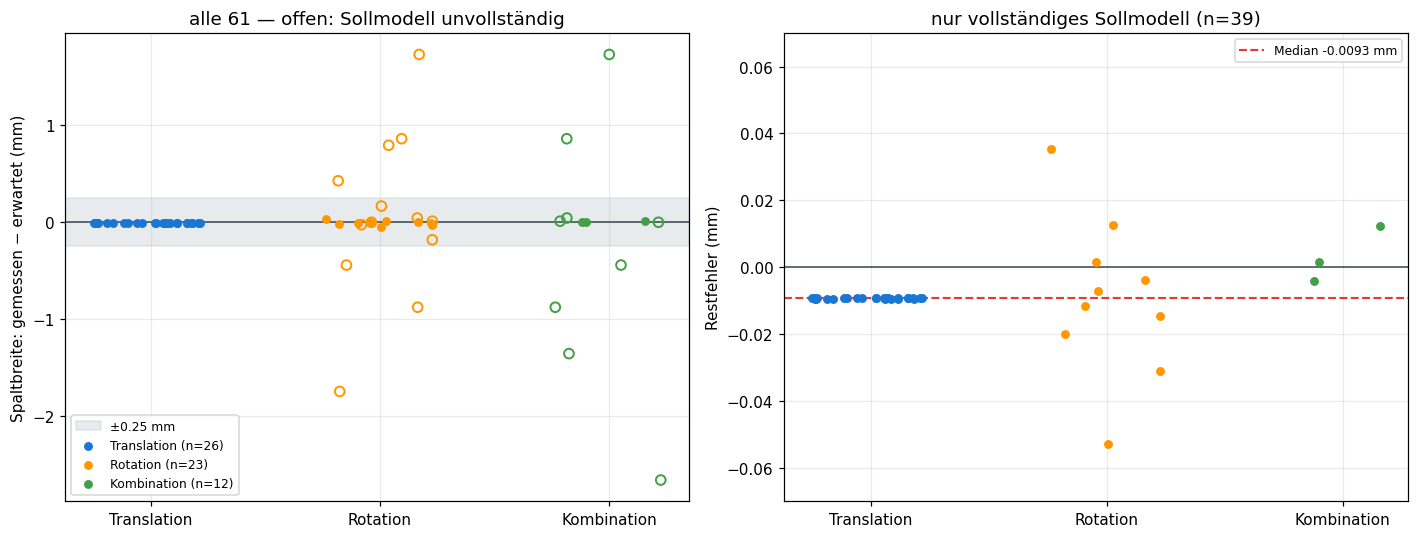

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=110)

ax = axes[0]
ax.axhspan(-TOLERANCE_MM, TOLERANCE_MM, color="#B0BEC5", alpha=0.3, zorder=0,
           label="±0.25 mm")
ax.axhline(0, color="#37474F", lw=1.0)
for i, cls in enumerate(CLASS_ORDER):
    sub = df[df.error_class == cls]
    a, b = sub[sub.gap_model_complete], sub[~sub.gap_model_complete]
    ax.scatter([i] * len(a) + np.random.default_rng(i).uniform(-.25, .25, len(a)),
               a.gap_residual_mm, color=CLASS_COLORS[cls], s=34, zorder=3,
               label=f"{cls} (n={len(sub)})", linewidths=0)
    ax.scatter([i] * len(b) + np.random.default_rng(i + 9).uniform(-.25, .25, len(b)),
               b.gap_residual_mm, facecolors="none", edgecolors=CLASS_COLORS[cls],
               s=40, linewidths=1.3, zorder=3)
ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_ORDER)
ax.set_ylabel("Spaltbreite: gemessen − erwartet (mm)")
ax.set_title("alle 61 — offen: Sollmodell unvollständig")
ax.legend(fontsize=8, loc="lower left"); ax.grid(alpha=0.25)

ax = axes[1]
for i, cls in enumerate(CLASS_ORDER):
    sub = full[full.error_class == cls]
    ax.scatter([i] * len(sub) + np.random.default_rng(i).uniform(-.25, .25, len(sub)),
               sub.gap_residual_mm, color=CLASS_COLORS[cls], s=34, zorder=3,
               linewidths=0)
ax.axhline(full.gap_residual_mm.median(), color="#E53935", ls="--", lw=1.4,
           label=f"Median {full.gap_residual_mm.median():+.4f} mm")
ax.axhline(0, color="#37474F", lw=1.0)
ax.set_ylim(-0.07, 0.07)
ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_ORDER)
ax.set_ylabel("Restfehler (mm)")
ax.set_title(f"nur vollständiges Sollmodell (n={len(full)})")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout()

## 2. Merkmale gegen die Ground Truth

Geprüft wird, wo die synthetischen Fälle einen bekannten Sollwert liefern:

| Merkmal | Sollwert |
|---|---|
| Kantenversatz | `tz` — nur bei rotationsfreien Fällen |
| Winkelsumme `(α_A−45°)+(α_B−45°)` | `rx` |
| Querverkippung | `−rx` |
| Verkippung längs der Naht | `ry` |
| Keilsteigung des Spalts | `−tan(rz)` |

In [4]:
pure_t = df[(df.rx_deg == 0) & (df.ry_deg == 0) & (df.rz_deg == 0)]
rx = df[df.rx_deg != 0]
pure_rz = df[(df.rz_deg != 0) & (df.ry_deg == 0)]

print("Kantenversatz vs. tz (ohne Rotation, n=%d):" % len(pure_t))
print(f"  Bias {(pure_t.edge_offset_mm - pure_t.tz_mm).mean():+.5f} mm, "
      f"Streuung {(pure_t.edge_offset_mm - pure_t.tz_mm).std():.6f} mm")

s, i = np.polyfit(rx.rx_deg, rx.angle_sum_err, 1)
print(f"\nWinkelsumme vs. rx (n={len(rx)}): Steigung {s:.5f}, Abschnitt {i:+.5f}°")
print(f"  max|Rest| {np.abs(rx.angle_sum_err - rx.rx_deg).max():.4f}°")

s, i = np.polyfit(df.rx_deg, -df.tilt_across_gap_deg, 1)
print(f"\nQuerverkippung vs. rx (n={len(df)}): Steigung {s:.5f}, Abschnitt {i:+.5f}°")

print(f"\nKeilsteigung vs. −tan(rz), nur rz (n={len(pure_rz)}): "
      f"max|Fehler| {pure_rz.wedge_slope_err.abs().max():.6f} mm/mm")

print("\nFlankenwinkel:")
for cls in CLASS_ORDER:
    s_ = df[df.error_class == cls]
    print(f"  {cls:14} A {s_.flank_a_angle_deg.min():.3f}…{s_.flank_a_angle_deg.max():.3f}°"
          f"   B {s_.flank_b_angle_deg.min():.3f}…{s_.flank_b_angle_deg.max():.3f}°")

Kantenversatz vs. tz (ohne Rotation, n=26):
  Bias +0.00729 mm, Streuung 0.000084 mm

Winkelsumme vs. rx (n=22): Steigung 0.99978, Abschnitt +0.00049°
  max|Rest| 0.0351°

Querverkippung vs. rx (n=61): Steigung 1.00053, Abschnitt -0.01640°

Keilsteigung vs. −tan(rz), nur rz (n=6): max|Fehler| 0.000014 mm/mm

Flankenwinkel:
  Translation    A 44.995…45.420°   B 44.568…45.005°
  Rotation       A 43.522…46.522°   B 44.347…45.495°
  Kombination    A 44.813…46.318°   B 44.038…45.248°


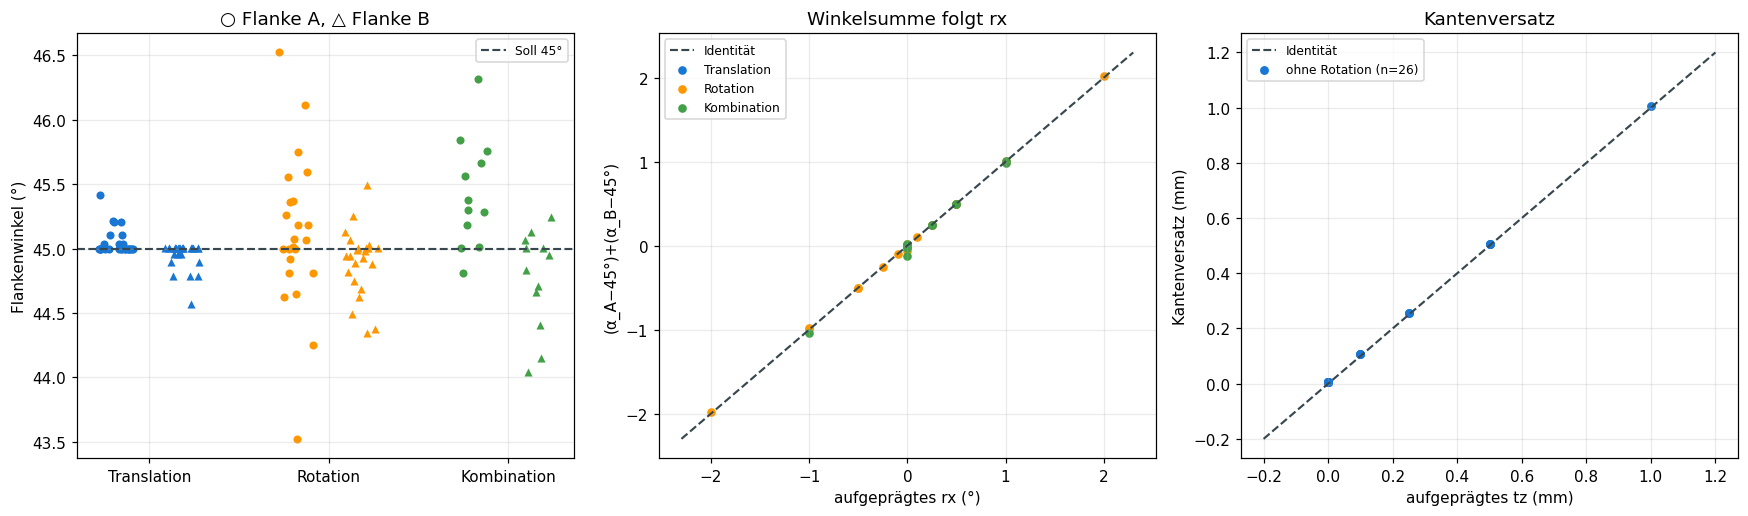

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), dpi=110)

ax = axes[0]
for i, cls in enumerate(CLASS_ORDER):
    sub = df[df.error_class == cls]
    for k, (col, mk) in enumerate((("flank_a_angle_deg", "o"), ("flank_b_angle_deg", "^"))):
        ax.scatter([i - .18 + .36 * k] * len(sub)
                   + np.random.default_rng(i + k).uniform(-.1, .1, len(sub)),
                   sub[col], color=CLASS_COLORS[cls], s=28, marker=mk, linewidths=0)
ax.axhline(45, color="#37474F", ls="--", lw=1.4, label="Soll 45°")
ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_ORDER)
ax.set_ylabel("Flankenwinkel (°)"); ax.set_title("○ Flanke A, △ Flanke B")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

ax = axes[1]
lim = [df.rx_deg.min() - .3, df.rx_deg.max() + .3]
ax.plot(lim, lim, color="#37474F", ls="--", lw=1.4, label="Identität")
for cls in CLASS_ORDER:
    sub = df[df.error_class == cls]
    ax.scatter(sub.rx_deg, sub.angle_sum_err, color=CLASS_COLORS[cls], s=32,
               linewidths=0, label=cls)
ax.set_xlabel("aufgeprägtes rx (°)"); ax.set_ylabel("(α_A−45°)+(α_B−45°)")
ax.set_title("Winkelsumme folgt rx"); ax.legend(fontsize=8); ax.grid(alpha=0.25)

ax = axes[2]
lim = [pure_t.tz_mm.min() - .2, pure_t.tz_mm.max() + .2]
ax.plot(lim, lim, color="#37474F", ls="--", lw=1.4, label="Identität")
ax.scatter(pure_t.tz_mm, pure_t.edge_offset_mm, color=CLASS_COLORS["Translation"],
           s=34, linewidths=0, label=f"ohne Rotation (n={len(pure_t)})")
ax.set_xlabel("aufgeprägtes tz (mm)"); ax.set_ylabel("Kantenversatz (mm)")
ax.set_title("Kantenversatz"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout()

## 3. Die drei Ebenen für zwei Beispielfälle

`T_X_+00.100mm` ist der günstigste Fall der Serie: eine Verschiebung von
0.1 mm *entlang* der Naht ändert die Nahtgeometrie nicht. `C_TR_08` kombiniert
`tz = 1.0 mm` mit `ry = 1.0°` und ist der einzige Fall mit unvollständiger
Bin-Abdeckung.

In [6]:
cols = ["case_name", "global_mean_abs", "global_in_tol_rate", "vox_frac_out_of_tol",
        "vox_worst_in_tol", "gap_residual_mm", "gap_model_complete",
        "flank_asymmetry_deg", "edge_offset_mm", "tilt_total_deg", "bin_coverage"]
sel = df[df.case_name.isin(["T_X_+00.100mm", "C_TR_08"])][cols]
print(sel.set_index("case_name").T.to_string())

case_name           T_X_+00.100mm   C_TR_08
global_mean_abs          0.000015  0.645307
global_in_tol_rate            1.0  0.294875
vox_frac_out_of_tol           0.0  0.715254
vox_worst_in_tol              1.0       0.0
gap_residual_mm         -0.009331 -1.357081
gap_model_complete           True     False
flank_asymmetry_deg      0.007692  1.801259
edge_offset_mm            0.00729  2.743711
tilt_total_deg            0.01581  1.000105
bin_coverage                  1.0      0.75


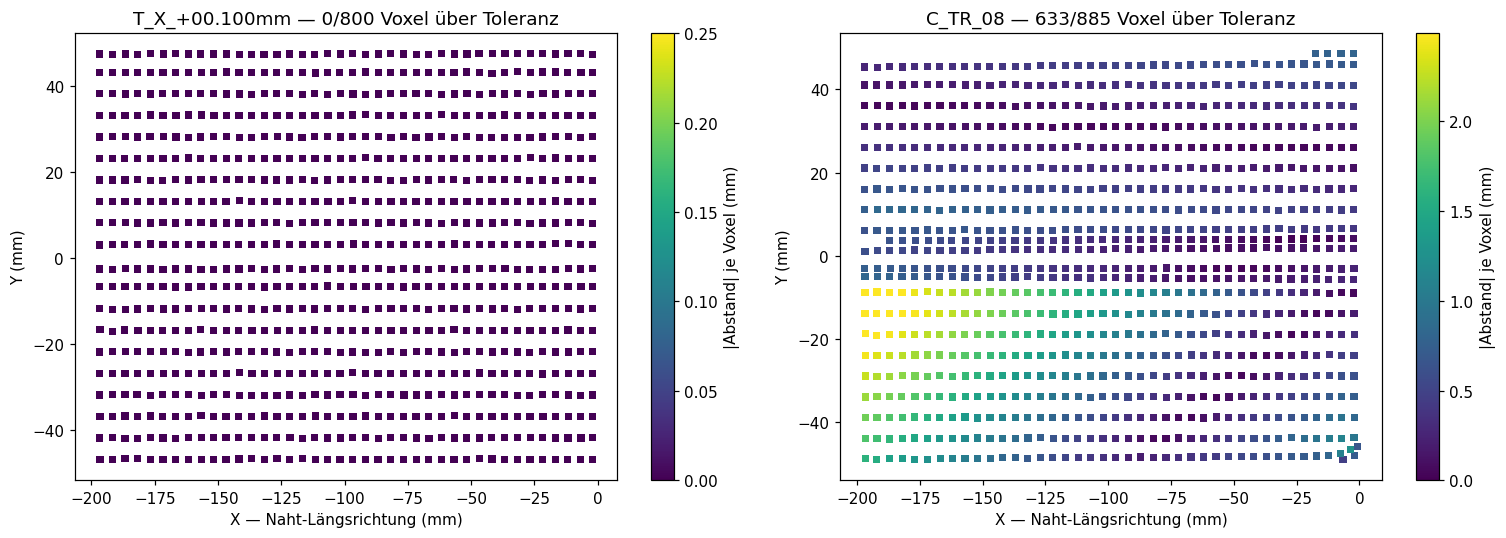

In [7]:
import json

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)
for ax, case in zip(axes, ["T_X_+00.100mm", "C_TR_08"]):
    with open(ROOT / "data" / "outputs" / case / "subtraction_report.json",
              encoding="utf-8") as fh:
        vox = json.load(fh)["deviation"]["voxel_deviation"]
    centers = np.array(vox["centers"])
    mean_abs = np.array(vox["mean_abs"], dtype=float)
    vmax = max(TOLERANCE_MM, float(np.nanpercentile(mean_abs, 99)))
    sc = ax.scatter(centers[:, 0], centers[:, 1], c=mean_abs, cmap="viridis",
                    s=22, marker="s", vmin=0, vmax=vmax, linewidths=0)
    plt.colorbar(sc, ax=ax, label="|Abstand| je Voxel (mm)")
    n_out = int((mean_abs > TOLERANCE_MM).sum())
    ax.set_title(f"{case} — {n_out}/{len(mean_abs)} Voxel über Toleranz")
    ax.set_xlabel("X — Naht-Längsrichtung (mm)"); ax.set_ylabel("Y (mm)")
fig.tight_layout()

## Befunde

**Der Restfehler der Spaltmessung hat Struktur — aber erst nach Abzug der
Geometrie.** Der ausgegebene Wurzelspalt wird auf `d_root` gemessen, das
oberhalb der echten Wurzel liegt; die dort abgelesene Breite ist deshalb um
`(5 mm − d_root)·2·tan(α)` grösser als das Nennmass — über die Serie 0.49 mm
bis 5.18 mm, je nach Fehlstellung. Das ist die V-Naht-Geometrie, kein
Messfehler, und es steckt bereits im Sollmodell aus Abschnitt 1. Erst *nach*
diesem Abzug bleibt der eigentliche Restfehler: über die 39 Fälle mit
vollständigem Sollmodell ein Median von **−0.0093 mm**. Die 26 reinen
Translationsfälle streuen darum praktisch nicht — auf vier Nachkommastellen
identisch. Die Rotationsfälle streuen mit ±0.05 mm rund fünfmal so weit. Der
Restfehler ist also kein Rauschen, sondern ein konstanter Versatz plus ein
rotationsabhängiger Anteil.

Wichtig für die Weiterverarbeitung: Die Spaltbreite ist ohne die zugehörige
Tiefe `d_root` nicht interpretierbar. Ein direkter Vergleich des Zahlenwerts
mit 1.5 mm läge schon im günstigsten Fall um das Doppelte der Toleranz daneben.

**Die einzelnen Flankenwinkel taugen nicht als Merkmal, ihre Summe schon.**
Bei aufgeprägter Querverkippung wandern beide Winkel, und zwar im Verhältnis
3:1 statt wie erwartet 0:1 — die Ausrichtung verteilt die Verkippung auf beide
Werkstücke. Ihre Summe dagegen trifft `rx` mit Steigung 0.99978 und einem
maximalen Rest von 0.035° über 22 Fälle.

**Die drei Ebenen sagen nicht dasselbe.** Bei `C_TR_08` liegt der globale
Kennwert bei 0.645 mm — daraus ist nicht ablesbar, *wo* das Bauteil abweicht.
Die Voxel-Ebene zeigt die Ursache: ein Gradient quer zur Naht, eine Hälfte
sauber, die andere um mehr als 2 mm daneben. Die Merkmalsebene benennt sie:
Kantenversatz 2.74 mm bei 1.0° Verkippung.